In [27]:
from pathlib import Path
from kaggle import api
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from fastai.tabular.core import add_datepart
from fastai.tabular.core import TabularPandas
from fastai.tabular.core import Categorify, FillMissing
from fastai.tabular.core import cont_cat_split

---
## Data Preprocessing 

In [2]:
data_dir = Path('datasets')
data_dir.mkdir(exist_ok=True, parents=False)

# Kaggle creds should already be saved to file ~/.kaggle/kaggle.json
# if not, check FastAI, (in book chapter 09 at time of writing), for steps to set up Kaggle. 
def get_bulldozers_data(data_dir:Path) -> Path:
    comp = 'bluebook-for-bulldozers'
    save_path = data_dir / comp
    if not save_path.exists():
        save_path.mkdir(exist_ok=True, parents=False)
        api.competition_download_cli(comp, path=save_path)
        shutil.unpack_archive(str(save_path.resolve()/f'{comp}.zip'), str(save_path))
    return save_path

def preprocess_data(train_data_path:Path, test_data_path:Path) -> TabularPandas:
    df = pd.read_csv(train_data_path, low_memory=False)
    df_test = pd.read_csv(test_data_path, low_memory=False)
    
    dep_var = 'SalePrice'
    fastai_preprocessing = [Categorify, FillMissing]
    sizes = 'Large','Large / Medium','Medium','Small','Mini','Compact'
    
    df['ProductSize'] = df['ProductSize'].astype('category')
    df['ProductSize'] = df['ProductSize'].cat.set_categories(sizes, ordered=True)
    df[dep_var] = np.log(df[dep_var])
    
    df = add_datepart(df, 'saledate')
    df_test = add_datepart(df_test, 'saledate')
    
    train_val_split_condition = (df.saleYear<2011) | (df.saleMonth<10)
    train_idx = np.where( train_val_split_condition)[0]
    valid_idx = np.where(~train_val_split_condition)[0]
    train_val_splits = (list(train_idx),list(valid_idx))
    
    cont,cat = cont_cat_split(df, 1, dep_var=dep_var)

    to = TabularPandas(df, fastai_preprocessing, cat, cont, 
                       y_names=dep_var, splits=train_val_splits)
    return to

In [3]:
save_path = get_bulldozers_data(data_dir)
print(f'Saved dataset to {str(save_path.resolve())} files:\n{[str(p.name) for p in save_path.iterdir()]}')

Saved dataset to /Users/seanmcmahon/repos/sean-mcmahon.github.io/notebooks/datasets/bluebook-for-bulldozers files:
['random_forest_benchmark_test.csv', 'Valid.csv', 'bluebook-for-bulldozers.zip', 'median_benchmark.csv', 'Valid.zip', 'TrainAndValid.7z', 'Test.csv', 'Train.7z', 'ValidSolution.csv', 'Machine_Appendix.csv', 'Valid.7z', 'Data Dictionary.xlsx', 'TrainAndValid.csv', 'Train.zip', 'TrainAndValid.zip']


In [4]:
train_df_path = save_path / 'TrainAndValid.csv'
test_df_path = save_path / 'Test.csv'
tabula_pandas = preprocess_data(train_df_path, test_df_path)

/Users/seanmcmahon/miniconda3/envs/sean-mcmahon.github.io/lib/python3.12/site-packages/fastai/tabular/core.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_field] = pd.to_datetime(df[date_field], infer_datetime_format=True)
/Users/seanmcmahon/miniconda3/envs/sean-mcmahon.github.io/lib/python3.12/site-packages/fastai/tabular/core.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_field] = pd.to_datetime(df[date_field], infer_datetime_format=True)
/Users/seanmcmahon/miniconda3/envs/sean-mcmahon.github.io/lib/python3.12/site-packages/fas

Check attributes are the same as Lesson 09 of Fastbook Tabular Data.

In [5]:
assert len(tabula_pandas.train) == 404710
assert len(tabula_pandas.valid) == 7988
expected_product_sizes = ['#na#', 'Large', 'Large / Medium', 'Medium', 'Small', 'Mini', 'Compact']
assert tabula_pandas.classes['ProductSize'] == expected_product_sizes
assert tabula_pandas.items.iloc[2,:].SalesID == 1139249
tabula_pandas.items.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,saleDayofyear,saleIs_month_end,saleIs_month_start,saleIs_quarter_end,saleIs_quarter_start,saleIs_year_end,saleIs_year_start,saleElapsed,auctioneerID_na,MachineHoursCurrentMeter_na
0,1139246,11.097410,999089,3157,121,3.0,2004,68.0,2,963,...,320,1,1,1,1,1,1,1.163635e+09,1,1
1,1139248,10.950807,117657,77,121,3.0,1996,4640.0,2,1745,...,86,1,1,1,1,1,1,1.080259e+09,1,1
2,1139249,9.210340,434808,7009,121,3.0,2001,2838.0,1,336,...,57,1,1,1,1,1,1,1.077754e+09,1,1
3,1139251,10.558414,1026470,332,121,3.0,2001,3486.0,1,3716,...,139,1,1,1,1,1,1,1.305763e+09,1,1
4,1139253,9.305651,1057373,17311,121,3.0,2007,722.0,3,4261,...,204,1,1,1,1,1,1,1.248307e+09,1,1


In [6]:
train_x,train_y = tabula_pandas.train.xs,tabula_pandas.train.y
valid_xs,valid_y = tabula_pandas.valid.xs,tabula_pandas.valid.y

Test on Sklearn to ensure all worky

In [7]:
sk_tree = DecisionTreeRegressor(max_leaf_nodes=4)
sk_tree.fit(train_x, train_y)

DecisionTreeRegressor(max_leaf_nodes=4)

In [8]:
help(sk_tree.tree_)

Help on Tree object:

class Tree(builtins.object)
 |  Array-based representation of a binary decision tree.
 |
 |  The binary tree is represented as a number of parallel arrays. The i-th
 |  element of each array holds information about the node `i`. Node 0 is the
 |  tree's root. You can find a detailed description of all arrays in
 |  `_tree.pxd`. NOTE: Some of the arrays only apply to either leaves or split
 |  nodes, resp. In this case the values of nodes of the other type are
 |  arbitrary!
 |
 |  Attributes
 |  ----------
 |  node_count : int
 |      The number of nodes (internal nodes + leaves) in the tree.
 |
 |  capacity : int
 |      The current capacity (i.e., size) of the arrays, which is at least as
 |      great as `node_count`.
 |
 |  max_depth : int
 |      The depth of the tree, i.e. the maximum depth of its leaves.
 |
 |  children_left : array of int, shape [node_count]
 |      children_left[i] holds the node id of the left child of node i.
 |      For leaves, childre

In [9]:
t = sk_tree.tree_.value
t.shape

(7, 1, 1)

[Text(0.6, 0.875, 'x[30] <= 0.5\nsquared_error = 0.482\nsamples = 404710\nvalue = 10.104'),
 Text(0.4, 0.625, 'x[57] <= 1991.5\nsquared_error = 0.417\nsamples = 360847\nvalue = 10.213'),
 Text(0.2, 0.375, 'squared_error = 0.375\nsamples = 155724\nvalue = 9.969'),
 Text(0.6, 0.375, 'x[6] <= 4.5\nsquared_error = 0.37\nsamples = 205123\nvalue = 10.398'),
 Text(0.4, 0.125, 'squared_error = 0.31\nsamples = 182403\nvalue = 10.495'),
 Text(0.8, 0.125, 'squared_error = 0.173\nsamples = 22720\nvalue = 9.622'),
 Text(0.8, 0.625, 'squared_error = 0.115\nsamples = 43863\nvalue = 9.208')]

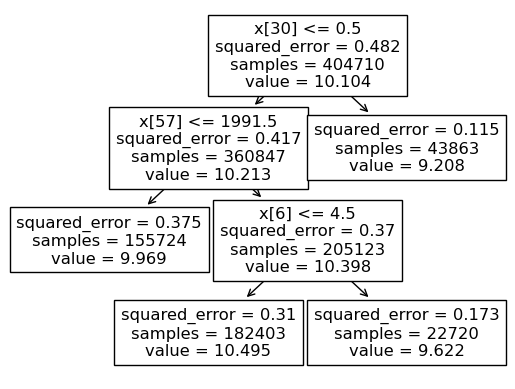

In [10]:
from sklearn.tree import plot_tree

plot_tree(sk_tree)

In [11]:
??sk_tree.tree_.predict

Signature: sk_tree.tree_.predict(X)
Docstring: Predict target for X.
Type:      method

---
## Decision Tree  

In [12]:
from abc import ABC
from abc import abstractmethod

class Metrics():
    @staticmethod
    def mse(y_pred:np.ndarray, y_gt:np.ndarray) -> np.float64:
        return ((y_pred - y_get)**2).mean()

    @staticmethod
    def root_mse(y_pred:np.ndarray, y_gt:np.ndarray) -> np.float64:
        return np.sqrt(Metrics.mse(y_pred, y_gt))

class DecisionTreeBase(ABC):
    def __init__(self, min_samples_leaf:int=1, max_leaf_nodes:int|None=None):
        self.min_samples_leaf = min_samples_leaf
        self.max_leaf_nodes = max_leaf_nodes

    @abstractmethod
    def fit(self, X, y):
        # X has shape (n_samples, n_features)
        # y has shape (n_samples,) or (n_samples, n_outputs)
        pass
        # While num_nodes < max_nodes:
        # select best feature base on heuristic
        # find best threshold of heuristic using Gini metric (MSE/L2)
        # Loop again 

    @abstractmethod
    def predict(self, X):
        # X of shape (n_samples, n_features)
        pass


In [78]:
from typing import NewType
from dataclasses import dataclass

from sklearn.tree._tree import Tree

class SkLearnDecisionTree(DecisionTreeBase):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.model = DecisionTreeRegressor(
            min_samples_leaf=self.min_samples_leaf,
            max_leaf_nodes=self.max_leaf_nodes)

    def fit(self, X, y):
        self.model.fit(X,y)

    def predict(self, X) -> np.ndarray:
        return self.model.predict(X)

sklean_dt = SkLearnDecisionTree(max_leaf_nodes=5)
sklean_dt.fit(train_x,train_y)
sk_y_pred_valid = sklean_dt.predict(valid_xs)

In [128]:
# %debug 
# TreeNode_ = NewType("TreeNode", object)
@dataclass
class TreeNode():
    # Data for this child from X[:, feature[i]] <= threshold[i]
    children_left_id: int | None = None
    # Data for this child X[:, feature[i]] > threshold[i]
    children_right_id: int | None = None
    feature_id:int = 0.
    threshold:float = 0.
    values: float | None = None
    index:int = 0


class PredictSkLearnDecisionTree(SkLearnDecisionTree):

    def _get_node(self,index:int) -> TreeNode:
        tree = self.model.tree_
        tn = TreeNode(
            children_left_id=tree.children_left[index],
            children_right_id=tree.children_right[index],
            feature_id=tree.feature[index],
            threshold=tree.threshold[index],
            values=tree.value[index],
            index=index
        )
        return tn

    def predict(self, Xdata: np.ndarray | pd.DataFrame) -> np.ndarray:
        if isinstance(Xdata, pd.DataFrame):
            Xdata = Xdata.to_numpy(copy=True)
        # My own re-implementation of predict using Sci-kit's tree.
        # Xdata of shape (n_samples, n_features)
        # Y (returned) of shape (n_samples,) or (n_samples, n_outputs)
        y_pred = np.zeros((Xdata.shape[0]))
        x_ids = np.arange(Xdata.shape[0])
        stack = [[self._get_node(0), x_ids]] # stack of [Node:TreeNode, data_at_node:np.ndarray]
        print(f'{self.model.tree_.node_count} nodes and {self.model.tree_.max_depth} depth to traverse')
        num_leaf_node_samples = 0
        leaf_node_samples = set()
        while stack:
            node, data_ids_at_node = stack.pop()
            is_split_node = node.children_left_id != node.children_right_id
            
            exp_samples = self.model.tree_.n_node_samples[node.index]
            split_n_str = 'Split' if is_split_node else 'Leaf'
            print(f'{split_n_str} node split {train_x.columns[node.feature_id]} ({node.feature_id}), '\
                 f'threshold: {node.threshold}, samples {data_ids_at_node.shape[0]} '\
                 f'({len(np.unique(data_ids_at_node))} unqiue) has values {node.values}')

            if is_split_node:
                data_left_ids = np.where(Xdata[data_ids_at_node, node.feature_id] <= node.threshold)[0]
                data_right_ids = np.where(Xdata[data_ids_at_node, node.feature_id] > node.threshold)[0]
                stack.append([self._get_node(node.children_left_id), data_left_ids])
                stack.append([self._get_node(node.children_right_id), data_right_ids])
            else:
                # num_leaf_node_samples += data_ids_at_node.shape[0]
                # if bool(set(tuple(data_ids_at_node.ravel().tolist())) & leaf_node_samples):
                #     print('Samples overlap!')
                #     import pdb; pdb.set_trace()
                # leaf_node_samples.update(tuple(data_ids_at_node.ravel().tolist()))
                # if len(leaf_node_samples) != num_leaf_node_samples:
                #     print('invalid number of leaf num samples!')
                #     import pdb; pdb.set_trace()
                # print(f'\tAdding {data_ids_at_node.shape} (?{data_ids_at_node.shape[0]*Xdata.shape[1]}?) '\
                #       f'predictions of {node.values}')
                
                y_pred[data_ids_at_node] = node.values.squeeze()
            # if node.children_left_id != -1:
            #     stack.append([self._get_node(node.children_left_id), data_left_ids])
            # else:
            #     y_pred[data_left_ids] = node.values
            
            # if node.children_right_id != -1:
            #     stack.append([self._get_node(node.children_right_id), data_right_ids])
            # else:
            #     y_pred[data_right_ids] = node.values
        print(f'Leaf nodes reached {num_leaf_node_samples} of {Xdata.shape[0]} samples '\
              f'{round(num_leaf_node_samples / Xdata.shape[0],3)}, unique samples {len(leaf_node_samples)}')
        # import pdb; pdb.set_trace()
        return y_pred


sklearn_mypred_dt = PredictSkLearnDecisionTree(max_leaf_nodes=5)
sklearn_mypred_dt.fit(train_x, train_y)
mypred_y_pred_valid = sklearn_mypred_dt.predict(valid_xs)
sk_pred_valid = sklearn_mypred_dt.model.predict(valid_xs)

9 nodes and 4 depth to traverse
Split node split Coupler_System (30), threshold: 0.5, samples 7988 (7988 unqiue) has values [[10.10434734]]
Leaf node split saleDayofyear (-2), threshold: -2.0, samples 1111 (1111 unqiue) has values [[9.20783802]]
Split node split YearMade (57), threshold: 1991.5, samples 6877 (6877 unqiue) has values [[10.21332314]]
Split node split ProductSize (6), threshold: 4.5, samples 5333 (5333 unqiue) has values [[10.39845074]]
Leaf node split saleDayofyear (-2), threshold: -2.0, samples 428 (428 unqiue) has values [[9.62239483]]
Split node split fiProductClassDesc (7), threshold: 8.5, samples 4905 (4905 unqiue) has values [[10.49511576]]
Leaf node split saleDayofyear (-2), threshold: -2.0, samples 3873 (3873 unqiue) has values [[10.71415398]]
Leaf node split saleDayofyear (-2), threshold: -2.0, samples 1032 (1032 unqiue) has values [[10.08044852]]
Leaf node split saleDayofyear (-2), threshold: -2.0, samples 1544 (1544 unqiue) has values [[9.96946908]]
Leaf nodes

In [130]:
def count_num_pred_values(value, pred_sk=sk_pred_valid, pred_me=mypred_y_pred_valid):
    c_sk = np.isclose(pred_sk,value).sum()
    c_me = np.isclose(pred_me,value).sum()
    print(f'For {str(value).ljust(18)}; Sklearn pred has {str(c_sk).ljust(4)} values, my predictor has {c_me} values')

un_val = np.unique(mypred_y_pred_valid)
for v in un_val: count_num_pred_values(v)

For 0.0               ; Sklearn pred has 0    values, my predictor has 2108 values
For 9.207838019401102 ; Sklearn pred has 1111 values, my predictor has 593 values
For 9.6223948275959   ; Sklearn pred has 681  values, my predictor has 24 values
For 9.969469080024961 ; Sklearn pred has 1544 values, my predictor has 1544 values
For 10.080448521413151; Sklearn pred has 1288 values, my predictor has 784 values
For 10.714153975894542; Sklearn pred has 3364 values, my predictor has 2935 values


In [105]:
7988 - (mypred_y_pred_valid == 0).sum()

5880

In [71]:
valid_xs.shape, (valid_xs.Coupler_System <= 0.5).sum()

((7988, 66), 6877)

In [72]:
train_x.shape, (train_x.Coupler_System <= 0.5).sum()

((404710, 66), 360847)

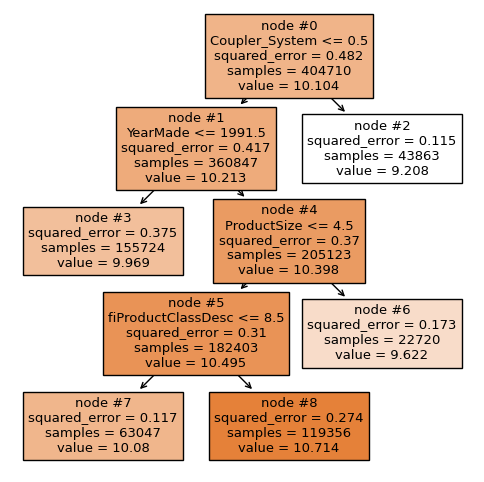

In [109]:
fig = plt.figure(figsize = (6, 6))
plot_tree(sklearn_mypred_dt.model, feature_names = train_x.columns,
              class_names = ['SalePrice'], filled = True, node_ids = True)
# plot_tree(sklearn_mypred_dt.model)
plt.show()